## Library

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

np.random.seed(42)

# 1. Import Dataset and Understand the Data

## 1.1. load dataset

In [2]:
df = pd.read_csv("./Food_Delivery_Time_Prediction.csv")
df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34


In [40]:
shape = df.shape
print(f"Rows : {shape[0]} \nColumns : {shape[1]}")

Rows : 200 
Columns : 18


In [4]:
print("Column name",df.columns.tolist())

Column name ['Order_ID', 'Customer_Location', 'Restaurant_Location', 'Distance', 'Weather_Conditions', 'Traffic_Conditions', 'Delivery_Person_Experience', 'Order_Priority', 'Order_Time', 'Vehicle_Type', 'Restaurant_Rating', 'Customer_Rating', 'Delivery_Time', 'Order_Cost', 'Tip_Amount']


In [5]:
print(df.dtypes)

Order_ID                          str
Customer_Location                 str
Restaurant_Location               str
Distance                      float64
Weather_Conditions                str
Traffic_Conditions                str
Delivery_Person_Experience      int64
Order_Priority                    str
Order_Time                        str
Vehicle_Type                      str
Restaurant_Rating             float64
Customer_Rating               float64
Delivery_Time                 float64
Order_Cost                    float64
Tip_Amount                    float64
dtype: object


## 1.2. Understand Dataset Structure

In [6]:
cat_cols = ['Weather_Conditions','Traffic_Conditions','Vehicle_Type','Order_Priority','Order_Time']

In [7]:
num_cols = ['Distance','Delivery_Person_Experience','Order_Cost','Tip_Amount', 'Restaurant_Rating', 'Customer_Rating']

# 2. Data Cleaning & Preprocessing
## 2.1. Check missing value

In [8]:
print(f"Missing value : {df.isnull().sum().sum()}")

Missing value : 0


## 2.2. Convert data types

In [9]:
df[num_cols] = df[num_cols].astype('float')
df[cat_cols] = df[cat_cols].astype('category')

In [10]:
print(df.dtypes)

Order_ID                           str
Customer_Location                  str
Restaurant_Location                str
Distance                       float64
Weather_Conditions            category
Traffic_Conditions            category
Delivery_Person_Experience     float64
Order_Priority                category
Order_Time                    category
Vehicle_Type                  category
Restaurant_Rating              float64
Customer_Rating                float64
Delivery_Time                  float64
Order_Cost                     float64
Tip_Amount                     float64
dtype: object


## 2.3. Check Duplicate

In [11]:
print("Any duplicate values",df.duplicated().sum())

Any duplicate values 0


## 2.4 Feature Engineering

In [12]:
def parse_coord(coord_str):
    return tuple(map(float, coord_str.strip('()').split(',')))

df[['cust_lat', 'cust_long']] = df['Customer_Location'].apply(parse_coord).apply(pd.Series)
df[['rest_lat', 'rest_long']] = df['Restaurant_Location'].apply(parse_coord).apply(pd.Series)

df.drop(columns=['Customer_Location','Restaurant_Location'], inplace=True)

In [13]:

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

df['Calculated_Distance'] = haversine(df['cust_lat'], df['cust_long'], df['rest_lat'], df['rest_long'])

# 3. Data transformation
## 3.1. Label Encoding

In [14]:
le = LabelEncoder()
scaler = StandardScaler()

In [15]:
for col in cat_cols:
    df[col] = le.fit_transform(df[col])
print(df.dtypes)
df.head()

Order_ID                          str
Distance                      float64
Weather_Conditions              int64
Traffic_Conditions              int64
Delivery_Person_Experience    float64
Order_Priority                  int64
Order_Time                      int64
Vehicle_Type                    int64
Restaurant_Rating             float64
Customer_Rating               float64
Delivery_Time                 float64
Order_Cost                    float64
Tip_Amount                    float64
cust_lat                      float64
cust_long                     float64
rest_lat                      float64
rest_long                     float64
Calculated_Distance           float64
dtype: object


,Order_ID,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,cust_lat,cust_long,rest_lat,rest_long,Calculated_Distance
0,ORD0001,1.57,1,2,4.0,2,0,2,4.1,3.0,26.22,1321.10,81.54,17.030479,79.743077,12.358515,85.100083,775.651198
1,ORD0002,21.32,0,2,8.0,1,3,2,4.5,4.2,62.61,152.21,29.02,15.398319,86.639122,14.174874,77.025606,1042.385597
2,ORD0003,6.95,2,2,9.0,0,3,1,3.3,3.4,48.43,1644.38,64.17,15.687342,83.888808,19.594748,82.048482,476.220706
3,ORD0004,13.79,0,1,2.0,2,1,1,3.2,3.7,111.63,541.25,79.23,20.415599,78.046984,16.915906,78.278698,389.912629
4,ORD0005,6.72,1,0,6.0,1,3,1,3.5,2.8,32.38,619.81,2.34,14.786904,78.706532,15.206038,86.203182,806.505886


## 3.2 Standardization (StandaerScaler)

In [16]:
df[num_cols] = scaler.fit_transform(df[num_cols])
df.head()

,Order_ID,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,cust_lat,cust_long,rest_lat,rest_long,Calculated_Distance
0,ORD0001,-1.454738,1,2,-0.456512,2,0,2,0.515500,-0.987317,26.22,0.501852,1.192403,17.030479,79.743077,12.358515,85.100083,775.651198
1,ORD0002,1.439192,0,2,1.004325,1,3,2,1.085900,0.738511,62.61,-1.634294,-0.600810,15.398319,86.639122,14.174874,77.025606,1042.385597
2,ORD0003,-0.666417,2,2,1.369535,0,3,1,-0.625302,-0.412041,48.43,1.092646,0.599332,15.687342,83.888808,19.594748,82.048482,476.220706
3,ORD0004,0.335835,0,1,-1.186930,2,1,1,-0.767902,0.019416,111.63,-0.923323,1.113532,20.415599,78.046984,16.915906,78.278698,389.912629
4,ORD0005,-0.700119,1,0,0.273907,1,3,1,-0.340101,-1.274955,32.38,-0.779755,-1.511757,14.786904,78.706532,15.206038,86.203182,806.505886


# 4. Exploratory Data Analysis (EDA)
## 4.1. Univariate Analysis


### Numerical Features

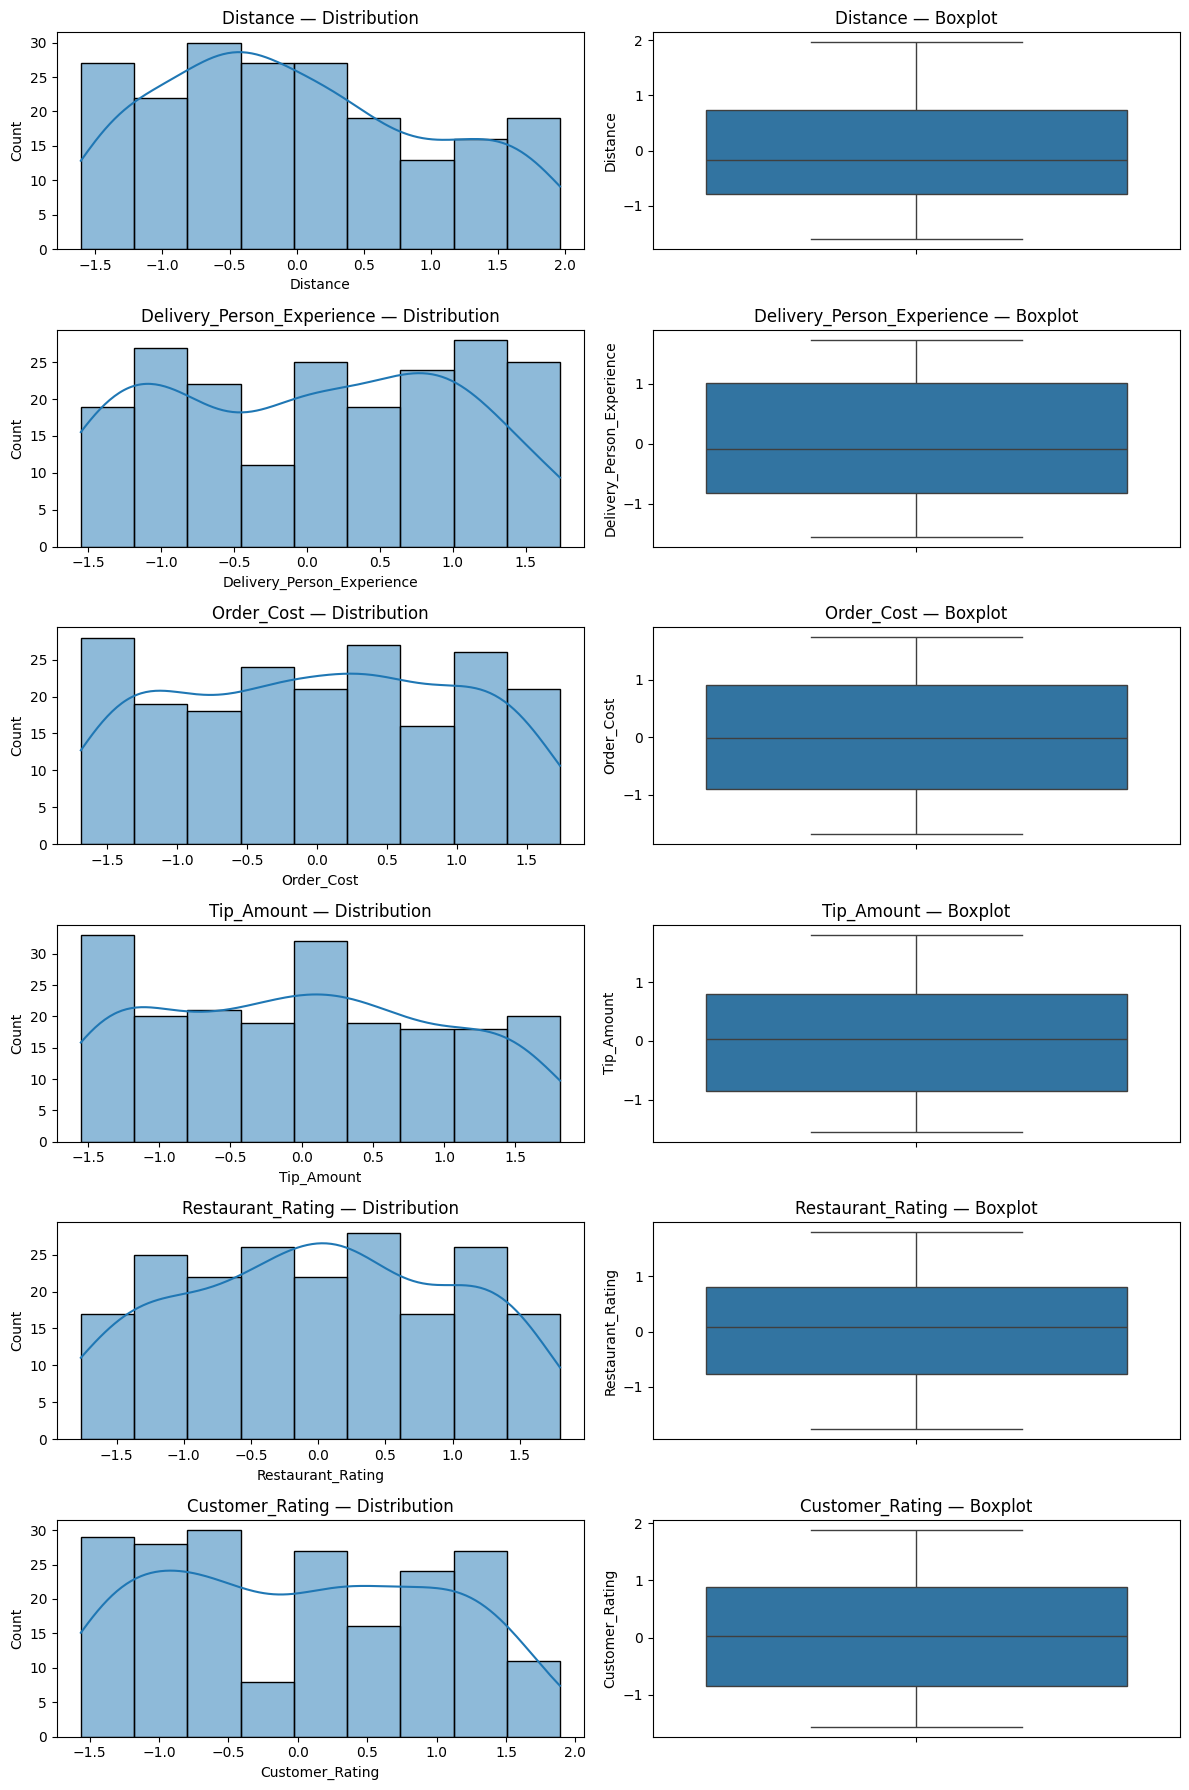

In [17]:
fix, axes = plt.subplots(
    nrows=len(num_cols),
    ncols=2,
    figsize = (12, len(num_cols) * 3)
)

for i , col in enumerate(num_cols):
    sns.histplot(data=df, x=col, ax=axes[i][0], kde=True)
    axes[i][0].set_title(f'{col} — Distribution')

    sns.boxplot(data=df, y=col, ax=axes[i][1])
    axes[i][1].set_title(f'{col} — Boxplot')

plt.tight_layout()
plt.show()

### Categorical Features

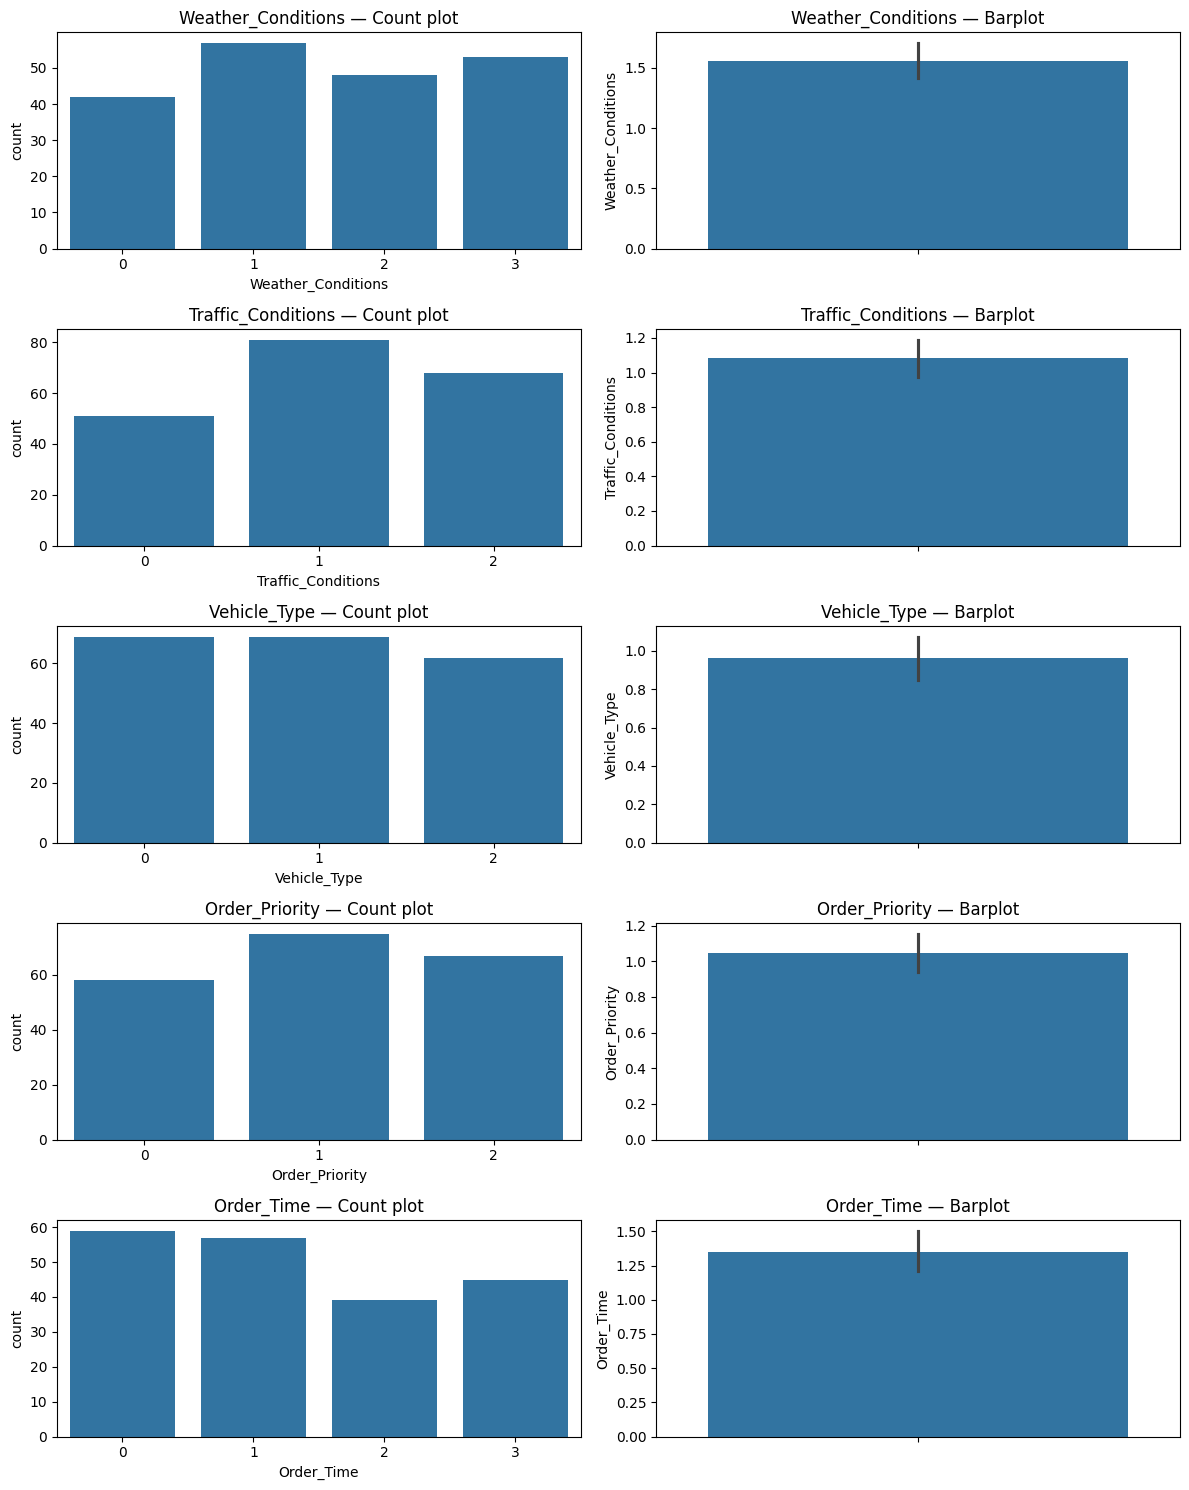

In [18]:
fix, axes = plt.subplots(
    nrows=len(cat_cols),
    ncols=2,
    figsize = (12, len(cat_cols) * 3)
)

for i , col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i][0])
    axes[i][0].set_title(f'{col} — Count plot')

    sns.barplot(data=df, y=col, ax=axes[i][1])
    axes[i][1].set_title(f'{col} — Barplot')

plt.tight_layout()
plt.show()

<Axes: xlabel='Delivery_Time'>

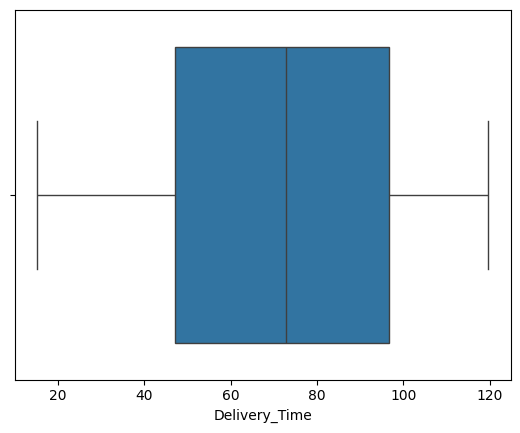

In [41]:
sns.boxplot(x=df['Delivery_Time'])

## 4.2 Descriptive Statistics

In [19]:
df.drop('Order_ID', axis=1, inplace=True)

In [20]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Distance,200.0,-1.643130e-16,1.002509,-1.608593,-0.792431,-0.180676,0.732560,1.963762
Weather_Conditions,200.0,1.560000e+00,1.096546,0.000000,1.000000,2.000000,3.000000,3.000000
Traffic_Conditions,200.0,1.085000e+00,0.768589,0.000000,0.000000,1.000000,2.000000,2.000000
Delivery_Person_Experience,200.0,4.440892e-18,1.002509,-1.552139,-0.821721,-0.091302,1.004325,1.734744
Order_Priority,200.0,1.045000e+00,0.791268,0.000000,0.000000,1.000000,2.000000,2.000000
Order_Time,200.0,1.350000e+00,1.128658,0.000000,0.000000,1.000000,2.000000,3.000000
Vehicle_Type,200.0,9.650000e-01,0.810593,0.000000,0.000000,1.000000,2.000000,2.000000
Restaurant_Rating,200.0,3.463896e-16,1.002509,-1.766103,-0.767902,0.087699,0.800700,1.798901
Customer_Rating,200.0,4.529710e-16,1.002509,-1.562593,-0.843498,0.019416,0.882330,1.889062
Delivery_Time,200.0,7.049495e+01,29.830694,15.230000,46.997500,72.775000,96.650000,119.670000


## 4.3 Correlation Analysis

In [21]:
df.corr()

,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,cust_lat,cust_long,rest_lat,rest_long,Calculated_Distance
Distance,1.000000,-0.011307,-0.075902,0.017562,-0.048920,0.216354,-0.137676,0.064676,0.003430,-0.075143,-0.022275,-0.006466,-0.081941,-0.029655,-0.114234,-0.058598,-0.022075
Weather_Conditions,-0.011307,1.000000,0.104224,0.053422,-0.110272,0.019489,0.061736,-0.069175,0.030321,-0.021580,0.065357,-0.081823,0.112553,-0.128075,0.037861,-0.050211,-0.028377
Traffic_Conditions,-0.075902,0.104224,1.000000,0.078004,-0.088949,0.029254,0.125787,0.005073,-0.039117,0.040023,0.042937,0.101626,0.132271,0.032482,-0.093516,-0.010995,-0.006646
Delivery_Person_Experience,0.017562,0.053422,0.078004,1.000000,-0.208797,-0.073799,0.003952,-0.004492,-0.122447,-0.019098,0.061015,-0.069218,-0.018154,-0.015311,-0.039637,-0.017127,-0.049197
Order_Priority,-0.048920,-0.110272,-0.088949,-0.208797,1.000000,-0.028978,0.041641,-0.009454,0.024795,-0.013405,-0.114597,0.086818,-0.043902,-0.045097,-0.023730,0.015498,0.017334
Order_Time,0.216354,0.019489,0.029254,-0.073799,-0.028978,1.000000,-0.162308,0.178625,0.011784,-0.008725,-0.088869,0.074252,0.023179,0.050730,0.121178,-0.032399,-0.008251
Vehicle_Type,-0.137676,0.061736,0.125787,0.003952,0.041641,-0.162308,1.000000,0.093203,0.088984,-0.055576,0.030383,-0.041956,-0.017714,0.034662,0.001731,0.034035,0.171352
Restaurant_Rating,0.064676,-0.069175,0.005073,-0.004492,-0.009454,0.178625,0.093203,1.000000,0.101661,-0.091855,-0.106870,-0.035759,-0.003811,0.024810,0.062694,-0.040985,0.037349
Customer_Rating,0.003430,0.030321,-0.039117,-0.122447,0.024795,0.011784,0.088984,0.101661,1.000000,-0.021952,0.142336,-0.074884,0.052605,-0.004770,0.107711,0.072579,-0.038964
Delivery_Time,-0.075143,-0.021580,0.040023,-0.019098,-0.013405,-0.008725,-0.055576,-0.091855,-0.021952,1.000000,-0.009307,-0.029154,-0.037146,0.008253,0.018548,0.083964,-0.170822


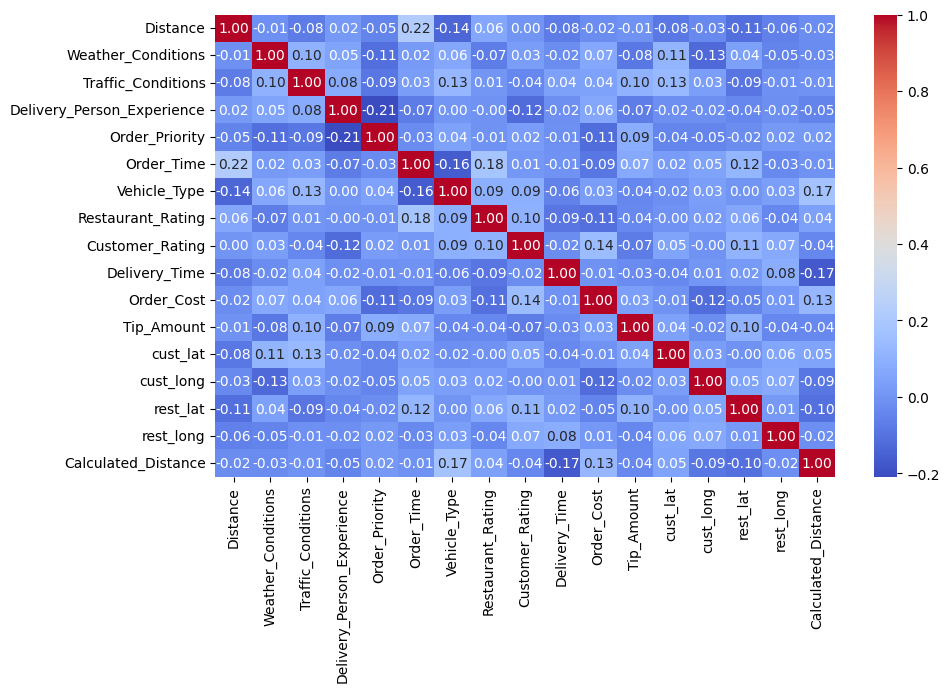

In [22]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

## 4.4. Bivariate Analysis

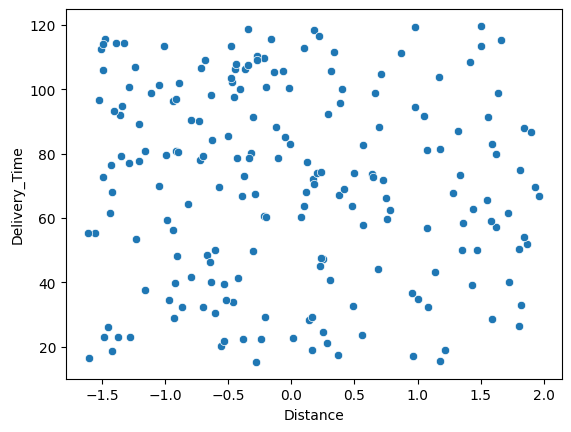

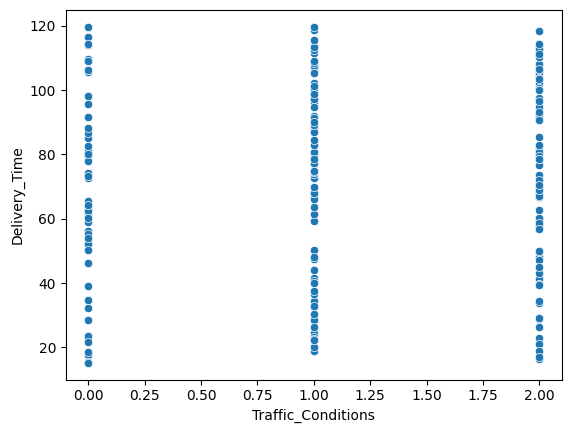

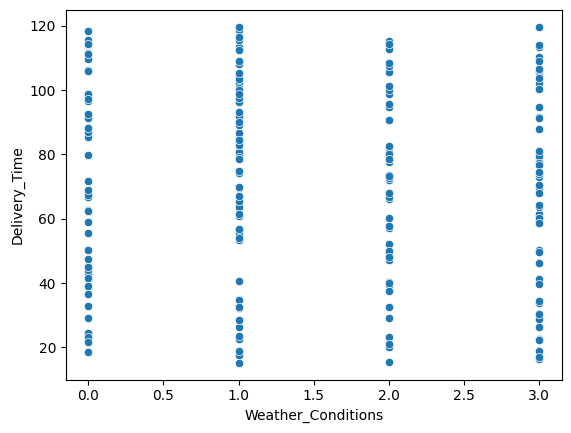

In [23]:
sns.scatterplot(data=df, x='Distance', y='Delivery_Time')
plt.show()
sns.scatterplot(data=df, x='Traffic_Conditions', y='Delivery_Time')
plt.show()
sns.scatterplot(data=df, x='Weather_Conditions', y='Delivery_Time')
plt.show()

In [24]:
df['Delivery_status'] = (df['Delivery_Time'] > 30).astype(int)
df['Delivery_status'].sample(15)

95     1
15     1
30     1
158    1
128    0
115    1
69     1
170    1
174    1
45     0
66     1
182    1
165    1
78     1
186    1
Name: Delivery_status, dtype: int64

## 5. Train test split
### 5.1 Data Split

In [25]:
X = df.drop(columns=['Delivery_Time', 'Delivery_status'])
y_lr = df["Delivery_Time"]
y_lgr = df['Delivery_status']

## 5.2 train test split

In [26]:
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X, y_lr,test_size=0.2, random_state=45)


In [27]:
bins = pd.qcut(y_lgr, q=4, duplicates='drop')
X_train_lgr, X_test_lgr, y_train_lgr, y_test_lgr = train_test_split(X, y_lgr, test_size=0.2, random_state=45, stratify=bins)

# 6. Model Building
## 6.1. Linear Regression

In [28]:
model_lr = LinearRegression()
model_lr.fit(X=X_train_lr, y=y_train_lr)
y_predict_lr = model_lr.predict(X_test_lr)

## 6.2 linerar regression evaluation

In [29]:
mae_lr = mean_absolute_error(y_test_lr, y_predict_lr)
mse_lr = mean_squared_error(y_test_lr, y_predict_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test_lr, y_predict_lr)

print(f"MAE: {mae_lr:.3f}\n",
      f"RMSE: {rmse_lr:.3f}\n",
      f"R² : {r2_lr:.3f}")


MAE: 30.089
 RMSE: 36.769
 R² : -0.369


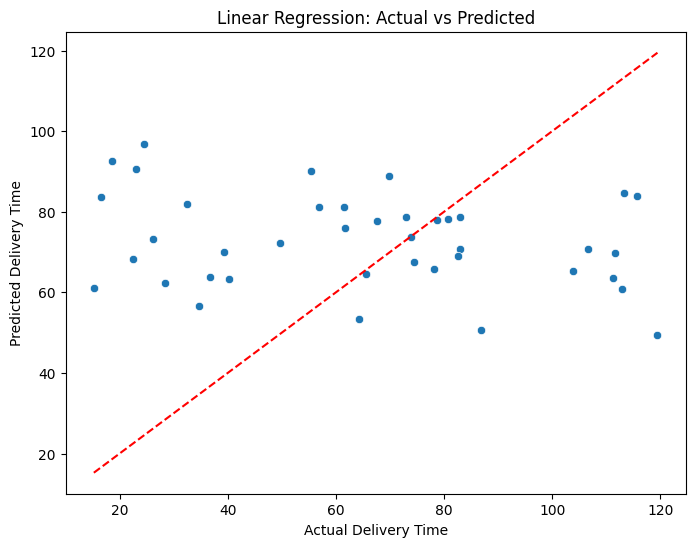

In [30]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test_lr, y=y_predict_lr)
plt.xlabel('Actual Delivery Time')
plt.ylabel('Predicted Delivery Time')
plt.title('Linear Regression: Actual vs Predicted')
plt.plot([y_test_lr.min(), y_test_lr.max()], [y_test_lr.min(), y_test_lr.max()], color='red', linestyle='--')
plt.show()

## 6.4 Logistic Regression

In [33]:
param_grid = {
    'penalty': ['l2'],
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs'],
    'max_iter': [500],
}

model_lgr = GridSearchCV(LogisticRegression(),
                    param_grid,
                    cv=5,
                    scoring='f1',
                    n_jobs=-1)

In [34]:
model_lgr.fit(X_train_lgr, y_train_lgr)
print("Best params:", model_lgr.best_params_)

Best params: {'C': 0.01, 'max_iter': 500, 'penalty': 'l2', 'solver': 'lbfgs'}


d:\Coding\Machine-Learning-Project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [36]:
y_predict_lgr = model_lgr.predict(X_test_lgr)
y_prob_log = model_lgr.predict_proba(X_test_lgr)[:,1]

## 6.5. Logistic Regression Evaluation

In [37]:
acc = accuracy_score(y_test_lgr, y_predict_lgr)
prec = precision_score(y_test_lgr, y_predict_lgr)
recall = recall_score(y_test_lgr, y_predict_lgr)
f1 = f1_score(y_test_lgr, y_predict_lgr)

print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1‑Score : {f1:.3f}")

Accuracy : 0.825
Precision: 0.825
Recall   : 1.000
F1‑Score : 0.904


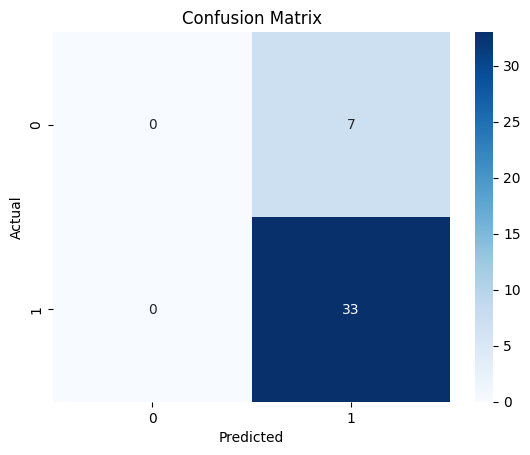

In [38]:
cm = confusion_matrix(y_test_lgr, y_predict_lgr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

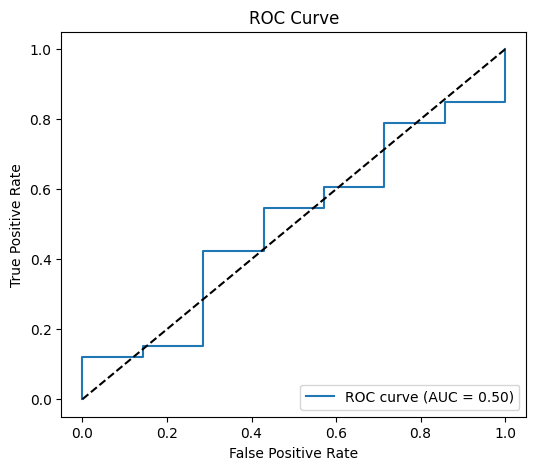

In [39]:
fpr, tpr, _ = roc_curve(y_test_lgr, y_prob_log)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

# Summary & Business Insights

- **Linear Regression**: Provides an estimate of delivery time in minutes. MAE ≈ *30.089*, R² ≈ *-0.369*.
- **Logistic Regression**: Classifies deliveries as Fast/Delayed. Accuracy ≈ *0.825*; AUC ≈ *0.50*.

**Key take‑aways for operations**:
1. *Distance + Traffic* are the strongest predictors of delay – consider dynamic routing.
2. *Weather* (Rainy/Snowy) increases delivery time; plan backup staff or vehicles.
3. *Delivery Person Experience* correlates with faster times – invest in training.
